In [9]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

def sigmoid(x, lambda_param):
    return 1 / (1 + np.exp(-lambda_param * x))

def IPT_metric(ipt_x, ipt_y, n_pts):
    num_directions = ipt_x.shape[0]
    
    # Calculate the sum of L2-norms for each direction
    total_dist = 0
    for i in range(num_directions):
        total_dist += np.linalg.norm(ipt_x[i] - ipt_y[i])/n_pts

    return total_dist / num_directions

def EMD(ipt_x, ipt_y, n_pts):
    num_directions = ipt_x.shape[0]

    total_dist = 0
    for i in range(ipt_x.shape[0]):
        total_dist += np.sum(np.abs(ipt_x[i]/n_pts - ipt_y[i]/n_pts)) 
    return total_dist / num_directions

def compute_medoid_chunked(ects, n_pts, batch=100):
    N = ects.shape[0]
    total_dist = np.zeros(N)

    for i in range(0, N, batch):
        batch_ects = ects[i:i+batch]

        diff = batch_ects[:, None] - ects[None]

        dir_norms = np.linalg.norm(diff, axis=-1)

        dists = dir_norms.mean(axis=-1)/n_pts

        total_dist[i:i+batch] = dists.sum(axis=1)

    return np.argmin(total_dist)

def pairwise_IPT(ects, n_pts, batch=100):
    N = ects.shape[0]
    pairwise_dist = np.zeros((N, N))

    for i in range(0, N, batch):
        print(f"Computing pairwise IPT distances for batch {i} to {min(i+batch, N)}...")
        batch_ects = ects[i:i+batch]

        diff = batch_ects[:, None] - ects[None]

        dir_norms = np.linalg.norm(diff, axis=-1)

        dists = dir_norms.mean(axis=-1)/n_pts

        pairwise_dist[i:i+batch] = dists
    return pairwise_dist

def pairwise_EMD(ects, n_pts, batch=100):
    N = ects.shape[0]
    pairwise_dist = np.zeros((N, N))

    for i in range(0, N, batch):
        print(f"Computing pairwise EMD distances for batch {i} to {min(i+batch, N)}...")
        batch_ects = ects[i:i+batch]

        diff = batch_ects[:, None] - ects[None]

        dir_norms = np.abs(diff).sum(axis=-1)

        dists = dir_norms.mean(axis=-1)/n_pts

        pairwise_dist[i:i+batch] = dists
    return pairwise_dist

class PointCloudPipeline:
    def __init__(self, num_directions=3, num_thresholds=32, radius=1.1, test_size=0.2):
        self.num_directions = num_directions
        self.num_thresholds = num_thresholds
        self.radius = radius
        self.test_size = test_size
        self.directions = self._generate_directions(self.num_directions)
        
        # Data and Features
        self.X_train, self.X_test = None, None
        self.y_train, self.y_test = None, None
        self.ect_train, self.ect_test = None, None
        
        # Classifiers
        self.rf_model = None
        self.svc_model = None

    def _generate_directions(self, n):
        """Generates n regular directions in 2D."""
        angles = np.linspace(0, 2*np.pi, n, endpoint=False)
        return np.stack((np.cos(angles), np.sin(angles)), axis=1)

    def load_and_preprocess(self, file_path):
        """Loads, splits, centers, and scales data."""
        data = np.load(file_path)
        X, y = data['points'], data['labels']
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=self.test_size, random_state=42
        )

        def scale_set(data):
            centered = data - data.mean(axis=1, keepdims=True)
            max_radii = np.max(np.linalg.norm(centered, axis=2, keepdims=True), axis=1, keepdims=True)
            return centered / max_radii
        

        self.X_train = scale_set(self.X_train)
        self.X_test = scale_set(self.X_test)
        return self

    # def _compute_ect(self, X):
    #     """Helper to compute ECT for a given dataset."""
    #     n_samples = X.shape[0]
    #     features = np.zeros((n_samples, self.num_directions, self.num_thresholds))
    #     for i in range(n_samples):
    #         for d_idx, d in enumerate(self.directions):
    #             dot_prods = np.dot(X[i], d)
    #             for th in range(self.num_thresholds):
    #                 a = -self.radius + (th/self.num_thresholds) * (2 * self.radius)
    #                 features[i, d_idx, th] = np.sum(dot_prods <= a)
    #     return features

    def _compute_ect(self, X):
        """
        Optimized ECT using vectorization and cumulative sums.
        X shape: (n_samples, n_points, 2)
        """
        n_samples, n_points, _ = X.shape
        thresholds = np.linspace(-self.radius, self.radius, self.num_thresholds)
        features = np.zeros((n_samples, self.num_directions, self.num_thresholds))

        for d_idx, d in enumerate(self.directions):
            # projections shape: (n_samples, n_points)
            projections = np.dot(X, d)
            
            for i in range(n_samples):
                bins = np.concatenate([[-np.inf], thresholds])
                counts, _ = np.histogram(projections[i], bins=bins)
                features[i, d_idx, :] = np.cumsum(counts)
                
        return features



    # def _compute_sect(self, X, lambda_val=10.0):
    #     n_samples, n_points, _ = X.shape
    #     thresholds = np.linspace(-self.radius, self.radius, self.num_thresholds)
    #     features = np.zeros((n_samples, self.num_directions, self.num_thresholds))
        
    #     for d_idx, d in enumerate(self.directions):
    #         projections = np.dot(X, d) 
            
    #         for t_idx, t in enumerate(thresholds):
    #             val = 1.0 / (1.0 + np.exp(-lambda_val * (t - projections)))                
    #             features[:, d_idx, t_idx] = np.sum(val, axis=1)
                
    #     return features

    def _compute_sect(self, X, lambda_val=10.0, n_jobs=-1):
        """
        Parallelized SECT using joblib.
        n_jobs=-1 uses all available CPU cores.
        """
        n_samples, n_points, _ = X.shape
        thresholds = np.linspace(-self.radius, self.radius, self.num_thresholds)
        
        # Define the work for a single sample
        def process_sample(sample_points):
            # Shape for one sample: (num_directions, num_thresholds)
            sample_features = np.zeros((self.num_directions, self.num_thresholds))
            for d_idx, d in enumerate(self.directions):
                projections = np.dot(sample_points, d)
                for t_idx, t in enumerate(thresholds):
                    # Sigmoid-based smoothing
                    val = 1.0 / (1.0 + np.exp(-lambda_val * (t - projections)))
                    sample_features[d_idx, t_idx] = np.sum(val)
            return sample_features

        # Execute in parallel
        results = Parallel(n_jobs=n_jobs)(
            delayed(process_sample)(X[i]) for i in range(n_samples)
        )
        
        # Stack results back into (n_samples, n_directions, n_thresholds)
        return np.array(results)
    

    def extract_features(self, use_smooth=False, lambda_val=10.0):
        """Computes and flattens features. use_smooth=True uses SECT."""
        mode = "SECT (Smooth)" if use_smooth else "ECT (Discrete)"
        print(f"Extracting {mode} features...")
        
        if use_smooth:
            self.ect_train = self._compute_sect(self.X_train, lambda_val)
            self.ect_test = self._compute_sect(self.X_test, lambda_val)
        else:
            self.ect_train = self._compute_ect(self.X_train)
            self.ect_test = self._compute_ect(self.X_test)
        return self
    
    def fit_and_evaluate_knn_classifier(self, k, metric='EMD'):
        """
        Classifies using k-Nearest Neighbors with SWD-like metrics.
        """
        print(f"Evaluating k-Nearest Neighbors Classifier (Metric: {metric})...")
        
        y_pred = []

        for i in range(self.ect_test.shape[0]):
            current_sample = self.ect_test[i]
            distances = []
            
            for j in range(self.ect_train.shape[0]):
                if metric == 'EMD':
                    dist = EMD(current_sample, self.ect_train[j], self.X_train.shape[1])
                else:
                    dist = IPT_metric(current_sample, self.ect_train[j], self.X_train.shape[1])
                distances.append((dist, self.y_train[j]))
                
            distances.sort(key=lambda x: x[0])  # Sort by distance
            neighbors = distances[:k]  # Get k nearest neighbors
            neighbor_labels = [label for _, label in neighbors]
            predicted_label = max(set(neighbor_labels), key=neighbor_labels.count)  # Majority vote
            #print(f"Sample {i}: Predicted={predicted_label}, True={self.y_test[i]}")
            y_pred.append(predicted_label)

        y_pred = np.array(y_pred)
        print(classification_report(self.y_test, y_pred))
        return y_pred

    
    def fit_and_evaluate_SWD_classifier(self, metric='EMD'):
        """
        Classifies using a Nearest Prototype approach with SWD-like metrics.
        """
        print(f"Evaluating Nearest Prototype Classifier (Metric: {metric})...")
        
        # Calculate Mean ECT for each class: shape (n_classes, n_dirs, n_thresholds)
        unique_labels = np.unique(self.y_train)
        prototypes = []
        for label in unique_labels:
            proto = compute_medoid_chunked(self.ect_train[self.y_train == label], self.X_train.shape[1], batch=500)
            prototypes.append(proto)
        prototypes = np.array(prototypes)

        y_pred = []
        n_pts = self.X_train.shape[1] # Assuming (samples, points, coords)

        for i in range(self.ect_test.shape[0]):
            current_sample = self.ect_test[i]
            distances = []
            
            for proto in prototypes:
                if metric == 'EMD':
                    dist = EMD(current_sample, proto, n_pts)
                else:
                    dist = IPT_metric(current_sample, proto, n_pts)
                distances.append(dist)
                
            y_pred.append(unique_labels[np.argmin(distances)])

        y_pred = np.array(y_pred)
        print(classification_report(self.y_test, y_pred))
        return y_pred


    def fit_random_forest(self, n_estimators=100, max_depth=None):
        """Fits a Random Forest on flattened ECT data."""
        print("Fitting Random Forest...")
        self.rf_model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
        train_features = self.ect_train.reshape(self.ect_train.shape[0], -1)
        self.rf_model.fit(train_features, self.y_train)
        return self

    def fit_svc(self, C=1.0, kernel='rbf'):
        """Fits an SVC on flattened ECT data."""
        print("Fitting SVC...")
        self.svc_model = SVC(C=C, kernel=kernel)
        train_features = self.ect_train.reshape(self.ect_train.shape[0], -1)
        self.svc_model.fit(train_features, self.y_train)
        return self

    def evaluate(self, model_type='rf'):
        """Tests the chosen model on the test ECT data."""
        model = self.rf_model if model_type == 'rf' else self.svc_model
        if model is None:
            raise ValueError(f"Model '{model_type}' has not been trained yet.")
        
        test_features = self.ect_test.reshape(self.ect_test.shape[0], -1)
        y_pred = model.predict(test_features)
        acc = accuracy_score(self.y_test, y_pred)
        print(f"--- {model_type.upper()} Evaluation ---")
        print(f"Accuracy: {acc:.4f}")
        print(classification_report(self.y_test, y_pred))
        return acc

In [80]:
# Example Execution:
pipeline = PointCloudPipeline(num_directions=9, num_thresholds=16)
pipeline.load_and_preprocess('mnist_512_pc.npz')
pipeline.extract_features(use_smooth=True, lambda_val=10.0)

Extracting SECT (Smooth) features...


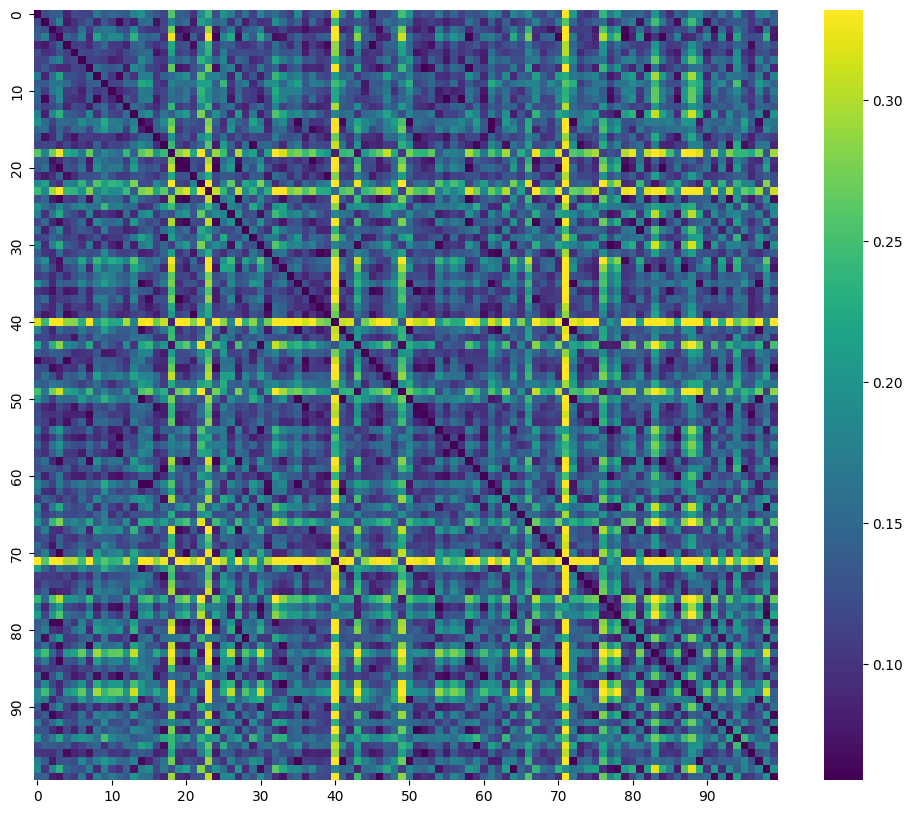

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(12, 10))
sns.heatmap(pairwise_IPT_distances[:100, :100], cmap='viridis', robust=True, xticklabels=10, yticklabels=10)
plt.show()

In [5]:
import pandas as pd
df = pd.DataFrame((pairwise_IPT_distances[:100, :100]), index=[f"Sample_{i}" for i in range(100)], columns=[f"Sample_{i}" for i in range(100)])
df['label'] = pipeline.y_test[:100]
df.head()

,Sample_0,Sample_1,Sample_2,Sample_3,Sample_4,Sample_5,Sample_6,Sample_7,Sample_8,Sample_9,...,Sample_91,Sample_92,Sample_93,Sample_94,Sample_95,Sample_96,Sample_97,Sample_98,Sample_99,label
Sample_0,0.000000,0.118977,0.136240,0.139877,0.087060,0.123673,0.114140,0.112723,0.168288,0.135804,...,0.113093,0.172052,0.126317,0.199776,0.118939,0.103184,0.177016,0.187588,0.139680,7
Sample_1,0.118977,0.000000,0.125730,0.176263,0.076442,0.096843,0.115225,0.135832,0.085577,0.133513,...,0.137013,0.111138,0.131913,0.132772,0.139766,0.100777,0.136965,0.101116,0.142865,3
Sample_2,0.136240,0.125730,0.000000,0.088084,0.110501,0.099934,0.160142,0.105089,0.157162,0.167896,...,0.061322,0.149706,0.092095,0.169755,0.136454,0.096476,0.075489,0.182791,0.080444,8
Sample_3,0.139877,0.176263,0.088084,0.000000,0.145121,0.129801,0.180365,0.089014,0.219260,0.165858,...,0.083412,0.191633,0.073261,0.221126,0.128017,0.120511,0.126490,0.234804,0.073663,9
Sample_4,0.087060,0.076442,0.110501,0.145121,0.000000,0.107537,0.110012,0.092595,0.125545,0.149902,...,0.105764,0.129573,0.116188,0.148577,0.136435,0.066614,0.127093,0.146205,0.120928,3


In [6]:
df.sort_values(by='label').index

Index(['Sample_30', 'Sample_18', 'Sample_40', 'Sample_60', 'Sample_49',
       'Sample_54', 'Sample_43', 'Sample_64', 'Sample_77', 'Sample_78',
       'Sample_98', 'Sample_76', 'Sample_71', 'Sample_35', 'Sample_61',
       'Sample_14', 'Sample_72', 'Sample_89', 'Sample_50', 'Sample_22',
       'Sample_97', 'Sample_10', 'Sample_65', 'Sample_92', 'Sample_42',
       'Sample_47', 'Sample_57', 'Sample_48', 'Sample_56', 'Sample_28',
       'Sample_53', 'Sample_27', 'Sample_26', 'Sample_21', 'Sample_1',
       'Sample_94', 'Sample_81', 'Sample_4', 'Sample_70', 'Sample_73',
       'Sample_95', 'Sample_63', 'Sample_32', 'Sample_16', 'Sample_66',
       'Sample_69', 'Sample_99', 'Sample_85', 'Sample_9', 'Sample_59',
       'Sample_46', 'Sample_51', 'Sample_25', 'Sample_34', 'Sample_11',
       'Sample_8', 'Sample_45', 'Sample_91', 'Sample_75', 'Sample_29',
       'Sample_24', 'Sample_58', 'Sample_55', 'Sample_12', 'Sample_93',
       'Sample_88', 'Sample_82', 'Sample_87', 'Sample_80', 'Sample_0

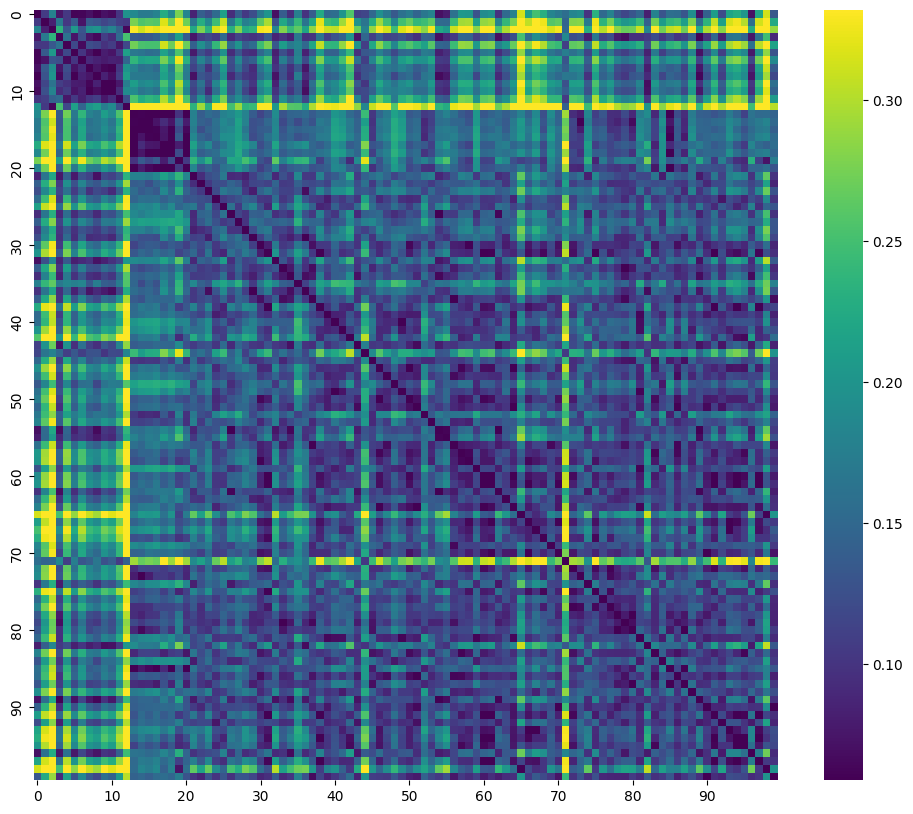

In [7]:
df.sort_values(by='label', inplace=True)
pwd  = np.zeros((100,100))
for i in range(100):
    for j,k in enumerate(df.sort_values(by='label').index): 
        pwd[i][j]  = df.iloc[i][k]
        #print(f"Row {i}, Col {j}, Label {df.loc[k]['label']}, Original Index {k}")

plt.figure(figsize=(12, 10))
sns.heatmap(pwd, cmap='viridis', robust=True, xticklabels=10, yticklabels=10)
plt.show()

In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_score

knn = KNeighborsClassifier(n_neighbors=5, metric='precomputed')
loo = LeaveOneOut()
scores = cross_val_score(knn, pairwise_IPT_distances, pipeline.y_test[:100], cv=loo)

accuracy = scores.mean()
print(f"Rotation-Invariant Classification Accuracy: {accuracy * 100:.2f}%")

Rotation-Invariant Classification Accuracy: 42.00%


In [14]:
def manual_knn_loo(dist_matrix, labels, k=5):
    n = dist_matrix.shape[0]
    predictions = []
    
    # Ensure labels is a numpy array for advanced indexing
    labels = np.asarray(labels)
    
    for i in range(n):
        row = dist_matrix[i]
        
        # 1. Get k-nearest neighbors (excluding the point itself at index 0)
        # Using argpartition is O(n) vs O(n log n) for argsort—faster for large matrices
        neighbor_indices = np.argpartition(row, k+1)[1:k+1]
        
        # 2. Get the labels of those neighbors
        neighbor_labels = labels[neighbor_indices]
        
        # 3. Majority Vote
        # np.bincount counts occurrences of each non-negative integer
        counts = np.bincount(neighbor_labels.astype(int))
        predictions.append(np.argmax(counts))
        
    return np.mean(np.array(predictions) == labels)

accuracy = manual_knn_loo(pairwise_IPT_distances_rot, pipeline.y_test)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 88.07%


## Multiple Prototypes

In [205]:
# choose a random sample of label l
label = 0
np.random.seed(42)  # For reproducibility
sam_id = np.random.choice(np.where(pipeline.y_train == label)[0])

sample = pipeline.ect_train[sam_id]   
cluster_distances = np.zeros(pipeline.X_train.shape[0])
non_cluster_distances = np.zeros(pipeline.X_train.shape[0])
for i in np.where(pipeline.y_train == label)[0]:
    min_dist = np.inf
    for k in range(pipeline.ect_train.shape[1]):
        d = IPT_metric(np.roll(pipeline.ect_train[i], k), sample, n_pts=pipeline.X_train.shape[1])
        if d < min_dist:
            min_dist = d
    cluster_distances[i] = min_dist
for j in np.where(pipeline.y_train != label)[0]:
    non_cluster_distances[j] = IPT_metric(pipeline.ect_train[j] , sample, n_pts=pipeline.X_train.shape[1])
max_distances = np.sort(cluster_distances)[-5:]# Exclude zeros from cluster_distances
min_non_cluster_dist = np.sort(non_cluster_distances[non_cluster_distances > 0])[:5]  # Exclude zeros

print(f"Max distance for label {label}: {max_distances}")
print(f"Min distance for non-cluster samples: {min_non_cluster_dist}")

p1 = sam_id 
t1 = min(max_distances[0], min_non_cluster_dist[4])

remaining_indices = np.where((pipeline.y_train == label) & (cluster_distances > t1))[0]
sam_id2 = np.random.choice(remaining_indices)

sample2 = pipeline.ect_train[sam_id2]
print(f"Sample 1 (Label {label}): {sample}")
print(f"Sample 2 (Label {label}): {sample2}")

cluster_distances2 = np.zeros(pipeline.X_train.shape[0])
non_cluster_distances2 = np.zeros(pipeline.X_train.shape[0])
for i in remaining_indices:
    cluster_distances2[i] = IPT_metric(pipeline.ect_train[i] , sample2, n_pts=pipeline.X_train.shape[1])
for j in np.where(pipeline.y_train != label)[0]:
    non_cluster_distances2[j] = IPT_metric(pipeline.ect_train[j] , sample2, n_pts=pipeline.X_train.shape[1])
max_distances2 = np.sort(cluster_distances2)[-5:]# Exclude zeros from cluster_distances
min_non_cluster_dist2 = np.sort(non_cluster_distances2[non_cluster_distances2 > 0])[:5]  # Exclude zeros

print(f"Max distance for label {label}: {max_distances2}")
print(f"Min distance for non-cluster samples: {min_non_cluster_dist2}")

p2 = sam_id2 
t2 = min(max_distances2[0], min_non_cluster_dist2[4])

print(f"p1: {p1}, t1: {t1}")
print(f"p2: {p2}, t2: {t2}")

remaining_indices2 = np.where((pipeline.y_train == label) & (cluster_distances2 > t2))[0]
print(f"Remaining indices for label {label} after second split: {remaining_indices2.shape[0]}")

Max distance for label 0: [0.38365253 0.3931686  0.3978445  0.40882354 0.41406952]
Min distance for non-cluster samples: [0.08618172 0.0882345  0.08896096 0.08946242 0.09191731]
Sample 1 (Label 0): [[  0.   0.   0.  10.  58. 132. 170. 225. 284. 332. 380. 457. 507. 512.
  512. 512.]
 [  0.   0.   0.   0.  11.  91. 166. 229. 280. 353. 429. 488. 512. 512.
  512. 512.]
 [  0.   5.  29.  77. 122. 158. 194. 242. 279. 310. 354. 396. 436. 471.
  507. 512.]]
Sample 2 (Label 0): [[  0.   0.  18.  67. 108. 142. 191. 220. 266. 314. 347. 418. 470. 512.
  512. 512.]
 [  0.   0.   0.  41. 105. 150. 184. 221. 260. 302. 374. 435. 491. 511.
  512. 512.]
 [  0.   1.  23.  65. 120. 169. 202. 236. 283. 316. 352. 392. 441. 481.
  509. 512.]]
Max distance for label 0: [0.41917422 0.41950995 0.42873762 0.43521518 0.49201557]
Min distance for non-cluster samples: [0.09111831 0.10586299 0.1101747  0.11111268 0.11702569]
p1: 8664, t1: 0.09191730886288206
p2: 40379, t2: 0.11702569481976278
Remaining indices for l

In [ ]:
import numpy as np
from joblib import Parallel, delayed

def EMD_vectorized_chunk(chunk, proto_rotations, n_pts, num_dirs):
    """
    Calculates the minimum distance between a chunk of samples and 
    all rotations of a prototype using 4D broadcasting.
    """
    # chunk: (chunk_size, D, T) -> (chunk_size, 1, D, T)
    # proto_rotations: (R, D, T) -> (1, R, D, T)
    diffs = np.abs(chunk[:, np.newaxis, :, :] - proto_rotations[np.newaxis, :, :, :])
    
    # Sum over directions (axis 2) and thresholds (axis 3)
    # Then take min over rotations (axis 1)
    # Result: (chunk_size,)
    dist_matrix = np.sum(diffs, axis=(2, 3)) / (n_pts * num_dirs)
    return np.min(dist_matrix, axis=1)

def compute_prototypes_label(pipeline, label, num_prototypes=20, K_neighbors=100, n_jobs=-1, chunk_size=500, min_pts=50, rotation = 2):
    """
    Computes a set of representative prototypes for a specific label.
    """
    all_class_indices = np.sort(np.where(pipeline.y_train == label)[0])
    non_class_indices = np.sort(np.where(pipeline.y_train != label)[0])
    remaining_indices = all_class_indices.copy()
    
    n_pts = pipeline.X_train.shape[1]
    num_dirs = pipeline.ect_train.shape[1]
    n_total_class = len(all_class_indices)
    
    prototypes = []
    p_idx = 0
    
    # Initialize with a random point from the class
    current_sam_id = np.random.choice(remaining_indices)

    while len(remaining_indices) > 100 and len(prototypes) < num_prototypes:
        # 1. Pre-calculate all cyclic rotations of the prototype signature
        proto_data = pipeline.ect_train[current_sam_id]
        proto_rotations = np.array([np.roll(proto_data, shift=k, axis=0) for k in range(rotation)])
        
        # 2. Parallel Internal Distance (Rotational Invariant)
        # Process all_class_indices in chunks to save RAM
        steps = range(0, n_total_class, chunk_size)
        results = Parallel(n_jobs=n_jobs, batch_size=1)(
            delayed(EMD_vectorized_chunk)(
                pipeline.ect_train[all_class_indices[s : s + chunk_size]], 
                proto_rotations, n_pts, num_dirs
            ) for s in steps
        )
        min_internal_dists = np.concatenate(results)

        # 3. External Distances (Fixed Alignment - Standard EMD)
        # Only compute once per prototype against non-class points
        external_block = pipeline.ect_train[non_class_indices]
        external_dists = np.sum(np.abs(external_block - proto_data), axis=(1, 2)) / (n_pts * num_dirs)

        # 4. Outlier/Ambiguity Check
        # Compare internal density vs proximity to other classes
        avg_int = np.sort(min_internal_dists)[1:K_neighbors+1].mean()
        valid_ext = external_dists[external_dists > 0]
        avg_ext = np.sort(valid_ext)[:K_neighbors].mean() if len(valid_ext) > 0 else np.inf
        
        if avg_int > avg_ext:
            print(f"   [Skip] ID {current_sam_id}: Prototype is non-distinct (Closer to other classes).")
            remaining_indices = np.setdiff1d(remaining_indices, [current_sam_id])
            if len(remaining_indices) > 0:
                current_sam_id = np.random.choice(remaining_indices)
            continue

        # 5. Dynamic Thresholding & Relaxation
        nearest_external = np.sort(valid_ext)[:10].mean() if len(valid_ext) > 0 else np.inf
        t = min(np.percentile(min_internal_dists, 20), nearest_external)
        
        def get_covered(threshold):
            # Map remaining to their positions in min_internal_dists
            idx_in_all = np.searchsorted(all_class_indices, remaining_indices)
            mask = min_internal_dists[idx_in_all] <= threshold
            return remaining_indices[mask]

        newly_covered = get_covered(t)

        # 6. Save Prototype and Update Coverage
        prototypes.append({
            'id': current_sam_id, 
            'threshold': t, 
            'internal_dists': min_internal_dists # Stored for Farthest-First selection
        })
        
        remaining_indices = np.setdiff1d(remaining_indices, newly_covered, assume_unique=True)
        print(f"   P{len(prototypes)} ID: {current_sam_id}, T: {t:.4f}, Covered: {len(newly_covered)}, Remaining: {len(remaining_indices)}")

        if len(remaining_indices) == 0:
            break
        
        # 7. Farthest First Selection
        if len(remaining_indices) > 0:
            # Subsample to keep it fast
            sub_size = min(2000, len(remaining_indices))
            sub_indices = np.random.choice(remaining_indices, sub_size, replace=False)
            
            # Use a small chunk of the ect_train to find the 'local hero'
            sub_block = pipeline.ect_train[sub_indices]
            
            # Calculate pairwise distances within the subsample (vectorized)
            # This finds which point is the "most central" to the remaining mass
            # (N_sub, 1, D, T) - (1, N_sub, D, T) -> sum and mean
            dist_matrix = np.sum(np.abs(sub_block[:, None] - sub_block[None, :]), axis=(2, 3))
            avg_dists = np.mean(dist_matrix, axis=1)
            
            # The new current_sam_id is the Medoid of this remaining group
            current_sam_id = sub_indices[np.argmin(avg_dists)]

    return prototypes

In [69]:
# --- Main Execution Block ---

prototypes = {}
labels = np.unique(pipeline.y_train)

for label in labels:
    print(f"\n--- Computing prototypes for label {label} ---")
    # Using chunk_size=500 for a balance between speed and 16GB-32GB RAM safety
    prototypes[label] = compute_prototypes_label(
        pipeline, 
        label, 
        num_prototypes=10, 
        K_neighbors=1000, 
        n_jobs=-1, # Use all CPU cores
        chunk_size=500,
        min_pts = 100
    )
    print(f"Finished label {label}: {[p['id'] for p in prototypes[label]]}")


--- Computing prototypes for label 0 ---
   P1 ID: 27023, T: 0.4251, Covered: 956, Remaining: 3792
   P2 ID: 18048, T: 0.2919, Covered: 877, Remaining: 2915
   P3 ID: 21182, T: 0.2834, Covered: 134, Remaining: 2781
   P4 ID: 6449, T: 0.2804, Covered: 45, Remaining: 2736
   P5 ID: 40590, T: 0.3071, Covered: 307, Remaining: 2429
   P6 ID: 33706, T: 0.2952, Covered: 167, Remaining: 2262
   P7 ID: 5259, T: 0.2960, Covered: 48, Remaining: 2214
   P8 ID: 12734, T: 0.3225, Covered: 215, Remaining: 1999
   P9 ID: 24272, T: 0.2615, Covered: 332, Remaining: 1667
   P10 ID: 24329, T: 0.2772, Covered: 1, Remaining: 1666
Finished label 0: [np.int64(27023), np.int64(18048), np.int64(21182), np.int64(6449), np.int64(40590), np.int64(33706), np.int64(5259), np.int64(12734), np.int64(24272), np.int64(24329)]

--- Computing prototypes for label 1 ---
   P1 ID: 47945, T: 0.2648, Covered: 831, Remaining: 4589
   P2 ID: 42025, T: 0.2265, Covered: 610, Remaining: 3979
   P3 ID: 12127, T: 0.2314, Covered: 3

In [70]:
from joblib import Parallel, delayed
import numpy as np
rotation = 2

def EMD(ipt_x, ipt_y, n_pts):
    # Vectorized L1 distance across all directions
    return np.sum(np.abs(ipt_x - ipt_y)) / (n_pts * ipt_x.shape[0])

def predict_single_sample(i, ect_test_sample, rotated_protos_cache, n_pts):
    min_dist_overall = np.inf
    closest_label_fallback = None
    votes = []

    for label, label_protos in rotated_protos_cache.items():
        for p in label_protos:
            # Vectorized search for the best rotation
            # p['shifts'] is (n_rotations, n_directions, n_thresholds)
            # test_sample is (n_directions, n_thresholds)
            # We calculate EMD for all rotations of this prototype at once
            dists = np.sum(np.abs(ect_test_sample - p['shifts']), axis=(1, 2)) / (n_pts * ect_test_sample.shape[0])
            dist = np.min(dists)
            
            if dist < min_dist_overall:
                min_dist_overall = dist
                closest_label_fallback = label
            
            if dist <= p['threshold']:
                votes.append(label)

    if votes:
        labels, counts = np.unique(votes, return_counts=True)
        return labels[np.argmax(counts)]
    return closest_label_fallback

# --- Setup for Parallel Execution ---

# 1. Pre-cache rotated prototypes as 3D numpy arrays for vectorization
rotated_protos_cache = {}
for label, label_protos in prototypes.items():
    rotated_protos_cache[label] = []
    for p in label_protos:
        proto_data = pipeline.ect_train[p['id']]
        # Create a 3D block: (n_rotations, directions, thresholds)
        shifts = np.array([np.roll(proto_data, shift=k, axis=0) for k in range(rotation)])
        rotated_protos_cache[label].append({
            'shifts': shifts,
            'threshold': p['threshold']
        })

# 2. Run Parallel Loop
n_pts = pipeline.X_train.shape[1]
y_pred = Parallel(n_jobs=-1)( # -1 uses all available CPU cores
    delayed(predict_single_sample)(i, pipeline.ect_test[i], rotated_protos_cache, n_pts) 
    for i in range(len(pipeline.ect_test))
)

y_pred = np.array(y_pred)

In [71]:
accuracy = accuracy_score(pipeline.y_test, y_pred)
print(f"Prototype-Based Classification Accuracy: {accuracy * 100:.2f}%")
print(classification_report(pipeline.y_test, y_pred))

Prototype-Based Classification Accuracy: 72.92%
              precision    recall  f1-score   support

           0       0.72      0.93      0.81      1175
           1       0.82      0.97      0.89      1322
           2       0.80      0.69      0.74      1174
           3       0.73      0.66      0.69      1219
           4       0.80      0.65      0.71      1176
           5       0.63      0.62      0.63      1104
           6       0.86      0.79      0.82      1177
           7       0.73      0.74      0.74      1299
           8       0.55      0.62      0.58      1160
           9       0.67      0.59      0.63      1194

    accuracy                           0.73     12000
   macro avg       0.73      0.73      0.72     12000
weighted avg       0.73      0.73      0.73     12000




--- PDF for label 0 ---


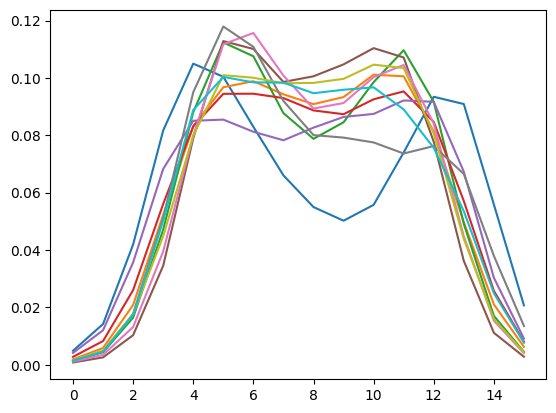


--- PDF for label 1 ---


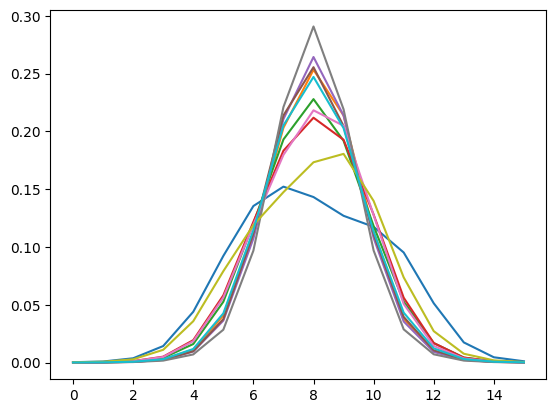


--- PDF for label 2 ---


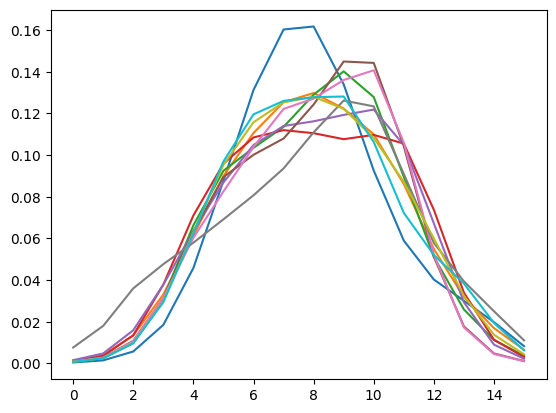


--- PDF for label 3 ---


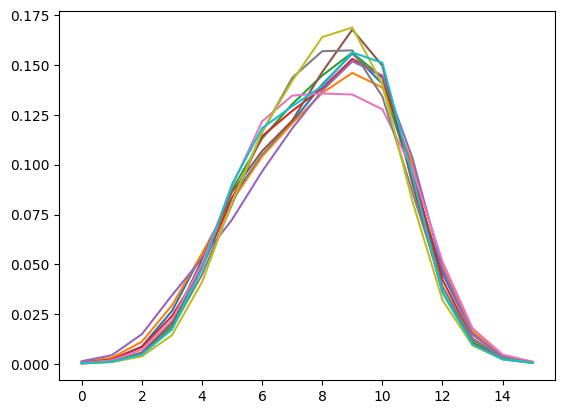


--- PDF for label 4 ---


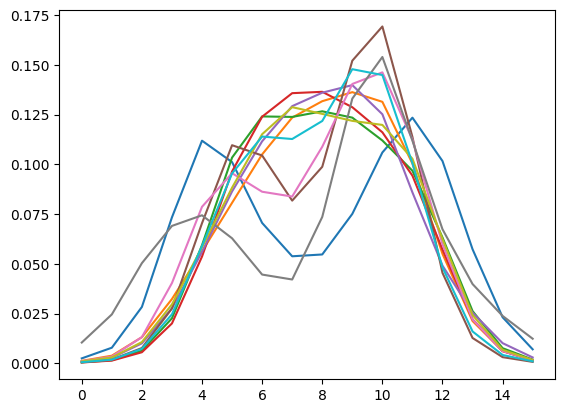


--- PDF for label 5 ---


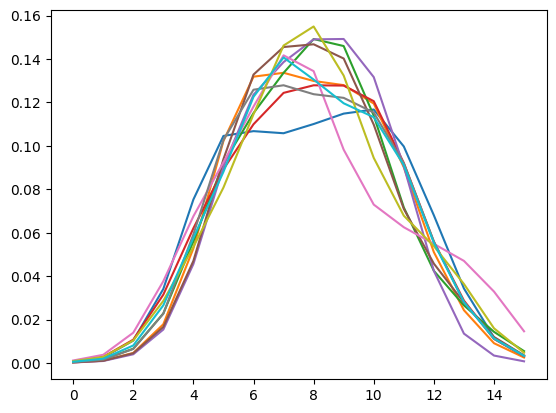


--- PDF for label 6 ---


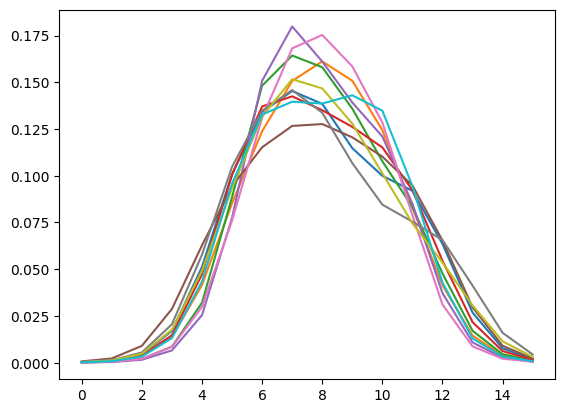


--- PDF for label 7 ---


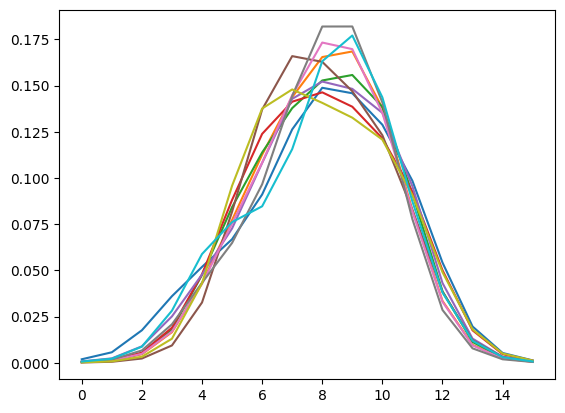


--- PDF for label 8 ---


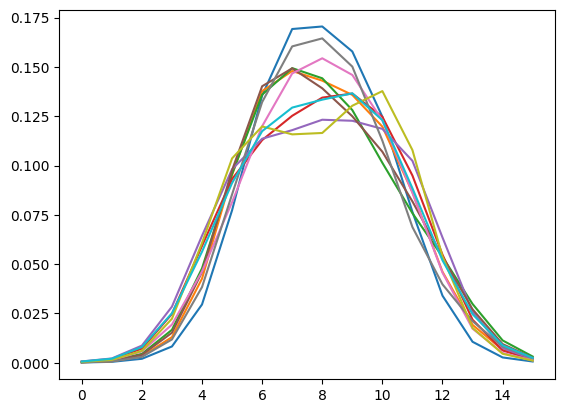


--- PDF for label 9 ---


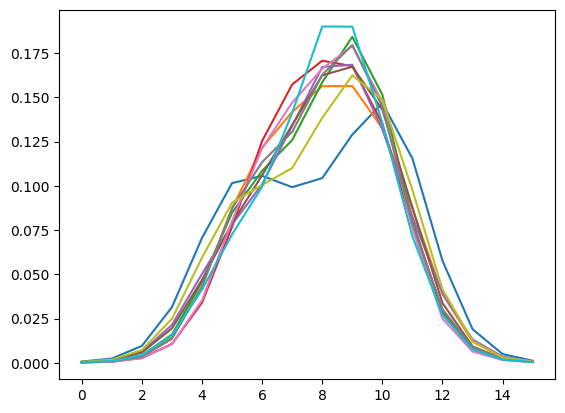

In [81]:
def get_pdf(ipt_x, n_pts):
    p = np.zeros(ipt_x.shape)
    for i in range(ipt_x.shape[0]):
        for j in range(ipt_x.shape[1]):
            p[i][j] = ipt_x[i][j] - ipt_x[i][j-1] if j > 0 else ipt_x[i][j]
    p /= n_pts
    return p

for label in labels:
    print(f"\n--- PDF for label {label} ---")
    label_protos = prototypes[label]
    for p in label_protos:
        proto_data = pipeline.ect_train[p['id']]
        pf = get_pdf(proto_data, 512)
        plt.plot(pf[0])
    plt.show()

## Decision Tree Like

In [149]:
def calculate_binary_entropy(labels, target_label):
    """Calculates entropy specifically for one label vs the rest."""
    if len(labels) == 0: return 0
    
    # 1. Create a binary mask: True for target, False for everything else
    is_target = (labels == target_label)
    
    # 2. Calculate the probability of the target label in this set
    p_target = np.mean(is_target)
    p_rest = 1 - p_target
    
    # 3. Standard Shannon Entropy formula
    if p_target == 0 or p_target == 1:
        return 0
    return - (p_target * np.log2(p_target) + p_rest * np.log2(p_rest))

In [ ]:
from scipy.stats import entropy

def find_best_ipt_split_ovr(X_ipt, y, target_label, num_ref_samples=10):
    n_samples, n_dirs, n_thresh = X_ipt.shape
    
    # Calculate parent entropy based ONLY on Target vs Rest
    parent_entropy = calculate_binary_entropy(y, target_label)
    
    best_gain = -1
    best_params = None
    
    # Choose references ONLY from the target label
    target_indices = np.where(y == target_label)[0]
    ref_indices = np.random.choice(target_indices, min(num_ref_samples, len(target_indices)), replace=False)

    for s_idx in ref_indices:
        S_ipt = X_ipt[s_idx]
        for k in range(n_dirs):
            # calculate kl divergence between the pdfs of the target and the rest for this direction
            
            distances = np.abs(X_ipt[:, k, :] - S_ipt[k, :]).sum(axis=1)
            
            # Use more granular thresholds to find a tight "envelope" around the target
            threshold_candidates = np.percentile(distances, [5, 10, 20, 30, 50])
            
            for t in threshold_candidates:
                left_mask = distances < t
                right_mask = ~left_mask
                
                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue
                
                # Binary Information Gain
                e_left = calculate_binary_entropy(y[left_mask], target_label)
                e_right = calculate_binary_entropy(y[right_mask], target_label)
                
                n = len(y)
                weighted_entropy = (len(y[left_mask])/n * e_left) + (len(y[right_mask])/n * e_right)
                print(f"Ref {s_idx}, Dir {k}, Th {t:.2f} => parent: {parent_entropy:.4f}, weighted: {weighted_entropy:.4f}")
                gain = parent_entropy - weighted_entropy
                
                if gain > best_gain:
                    best_gain = gain
                    best_params = {'ref_idx': s_idx, 'direction': k, 'threshold': t, 'label': target_label}
                    
    return best_params, best_gain, left_mask, right_mask

In [133]:
all_splits = []

for label in np.unique(pipeline.y_train):
    bp, g, left_mask, right_mask = find_best_ipt_split_ovr(pipeline.ect_train, pipeline.y_train, target_label=label)
    if bp is not None:
        # Map s_idx back to the global index if needed, 
        # but storing the feature vector is safer
        bp['S_vector'] = pipeline.ect_train[bp['ref_idx']]
        bp['source_label'] = label
        all_splits.append((g, bp, left_mask, right_mask))

# Sort by gain descending and pick the winner
all_splits.sort(key=lambda x: x[0], reverse=True)
absolute_best_gain, absolute_best_params, b_left, b_right = all_splits[0]

print(f"Global Best Split found using label {absolute_best_params['source_label']}")

Ref 29120, Dir 0, Th 186.00 => parent: 0.4656, weighted: 0.4056
Ref 29120, Dir 0, Th 238.00 => parent: 0.4656, weighted: 0.3719
Ref 29120, Dir 0, Th 326.00 => parent: 0.4656, weighted: 0.3421
Ref 29120, Dir 0, Th 397.00 => parent: 0.4656, weighted: 0.3429
Ref 29120, Dir 0, Th 511.00 => parent: 0.4656, weighted: 0.3780
Ref 29120, Dir 1, Th 186.00 => parent: 0.4656, weighted: 0.4424
Ref 29120, Dir 1, Th 242.00 => parent: 0.4656, weighted: 0.4429
Ref 29120, Dir 1, Th 328.00 => parent: 0.4656, weighted: 0.4444
Ref 29120, Dir 1, Th 410.00 => parent: 0.4656, weighted: 0.4457
Ref 29120, Dir 1, Th 542.00 => parent: 0.4656, weighted: 0.4511
Ref 29120, Dir 2, Th 129.00 => parent: 0.4656, weighted: 0.4160
Ref 29120, Dir 2, Th 165.00 => parent: 0.4656, weighted: 0.3925
Ref 29120, Dir 2, Th 228.00 => parent: 0.4656, weighted: 0.3664
Ref 29120, Dir 2, Th 293.00 => parent: 0.4656, weighted: 0.3572
Ref 29120, Dir 2, Th 438.00 => parent: 0.4656, weighted: 0.3770
Ref 15121, Dir 0, Th 133.00 => parent: 0

In [118]:
all_splits

[(np.float64(0.18340122646637202),
  {'ref_idx': np.int64(39844),
   'direction': 0,
   'threshold': np.float64(347.0),
   'label': np.int32(1),
   'S_vector': array([[  0.,   0.,   0.,   0.,   0.,   0.,   0., 115., 424., 471., 511.,
           512., 512., 512., 512., 512.],
          [  0.,   0.,  11.,  43.,  80., 126., 166., 218., 273., 335., 375.,
           428., 496., 512., 512., 512.],
          [  0.,   3.,  48.,  69., 107., 138., 178., 215., 270., 308., 357.,
           419., 471., 501., 512., 512.]]),
   'source_label': np.int32(1)},
  array([ True,  True,  True, ...,  True,  True,  True], shape=(48000,)),
  array([False, False, False, ..., False, False, False], shape=(48000,))),
 (np.float64(0.16861525880925593),
  {'ref_idx': np.int64(3199),
   'direction': 0,
   'threshold': np.float64(584.0),
   'label': np.int32(0),
   'S_vector': array([[  0.,   0.,  35.,  97., 119., 195., 226., 256., 275., 303., 333.,
           367., 415., 450., 508., 512.],
          [  0.,   0.,   0.

In [129]:
label = 2
counts_left = np.bincount(pipeline.y_train[all_splits[label][2]].astype(int))
counts_right = np.bincount(pipeline.y_train[all_splits[label][3]].astype(int))    
print(f"Left: {counts_left}, Right: {counts_right}")

Left: [ 588 2040 2499  775 4413 2861 4646  822 2042 3217], Right: [4160 3380 2285 4137  253 1456   95 4144 2649 1538]


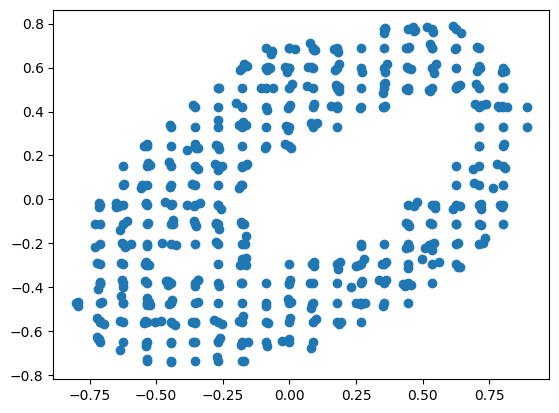

In [87]:
label = 0
ref_id = all_splits[label][1]['ref_idx']
sample = pipeline.X_train[pipeline.y_train == label][ref_id]
plt.scatter(sample[:, 0], sample[:, 1])

In [5]:
y_pred = pipeline.fit_and_evaluate_SWD_classifier(metric='IPT')

Evaluating Nearest Prototype Classifier (Metric: IPT)...
              precision    recall  f1-score   support

           0       0.79      0.84      0.81      1175
           1       0.71      0.81      0.76      1322
           2       0.78      0.57      0.66      1174
           3       0.45      0.61      0.52      1219
           4       0.61      0.72      0.66      1176
           5       0.54      0.36      0.44      1104
           6       0.80      0.79      0.79      1177
           7       0.80      0.67      0.73      1299
           8       0.47      0.44      0.45      1160
           9       0.61      0.64      0.63      1194

    accuracy                           0.65     12000
   macro avg       0.66      0.65      0.64     12000
weighted avg       0.66      0.65      0.65     12000



In [9]:
y_pred_knn = pipeline.fit_and_evaluate_knn_classifier(k=5, metric='IPT')

Evaluating k-Nearest Neighbors Classifier (Metric: IPT)...
Sample 0: Predicted=7, True=7
Sample 1: Predicted=3, True=3
Sample 2: Predicted=8, True=8
Sample 3: Predicted=9, True=9
Sample 4: Predicted=3, True=3
Sample 5: Predicted=9, True=9
Sample 6: Predicted=7, True=7
Sample 7: Predicted=7, True=7
Sample 8: Predicted=5, True=5
Sample 9: Predicted=4, True=4
Sample 10: Predicted=2, True=2
Sample 11: Predicted=5, True=5
Sample 12: Predicted=6, True=6
Sample 13: Predicted=8, True=8
Sample 14: Predicted=1, True=1
Sample 15: Predicted=7, True=7
Sample 16: Predicted=4, True=4
Sample 17: Predicted=4, True=8
Sample 18: Predicted=0, True=0
Sample 19: Predicted=7, True=7
Sample 20: Predicted=9, True=9
Sample 21: Predicted=3, True=3
Sample 22: Predicted=1, True=1
Sample 23: Predicted=7, True=7
Sample 24: Predicted=6, True=6
Sample 25: Predicted=8, True=5
Sample 26: Predicted=8, True=3
Sample 27: Predicted=7, True=3
Sample 28: Predicted=3, True=3
Sample 29: Predicted=6, True=6
Sample 30: Predicted=

KeyboardInterrupt: 

In [37]:
pipeline.fit_and_evaluate_SWD_classifier(metric='EMD')

Evaluating Nearest Prototype Classifier (Metric: EMD)...
              precision    recall  f1-score   support

           0       0.58      0.76      0.66      1175
           1       0.68      0.84      0.75      1322
           2       0.82      0.48      0.60      1174
           3       0.54      0.58      0.56      1219
           4       0.68      0.75      0.71      1176
           5       0.59      0.34      0.43      1104
           6       0.80      0.76      0.78      1177
           7       0.82      0.58      0.68      1299
           8       0.36      0.43      0.39      1160
           9       0.53      0.65      0.58      1194

    accuracy                           0.62     12000
   macro avg       0.64      0.62      0.62     12000
weighted avg       0.64      0.62      0.62     12000



array([7, 3, 8, ..., 9, 9, 2])

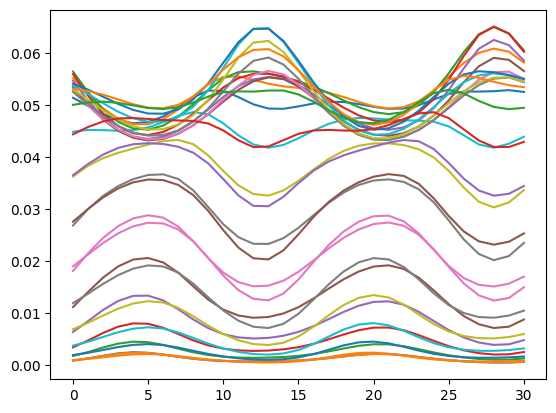

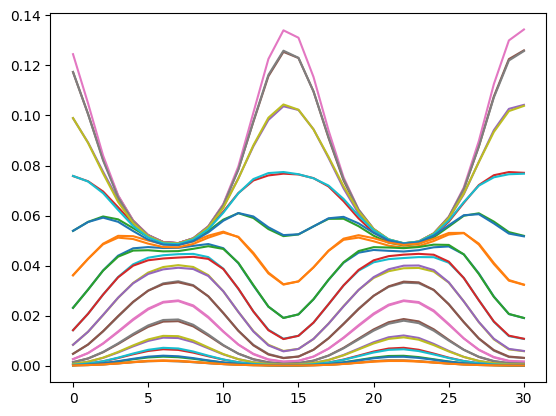

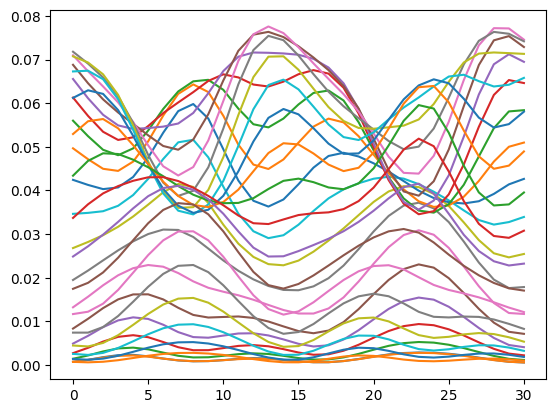

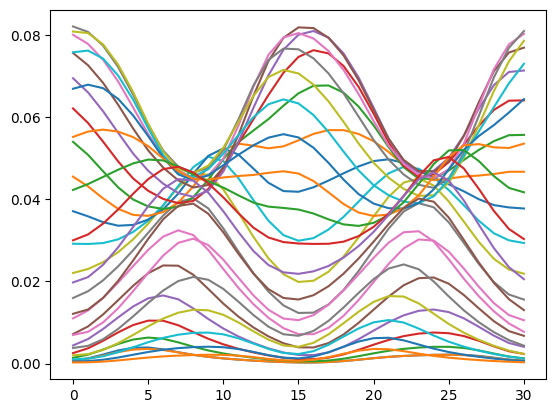

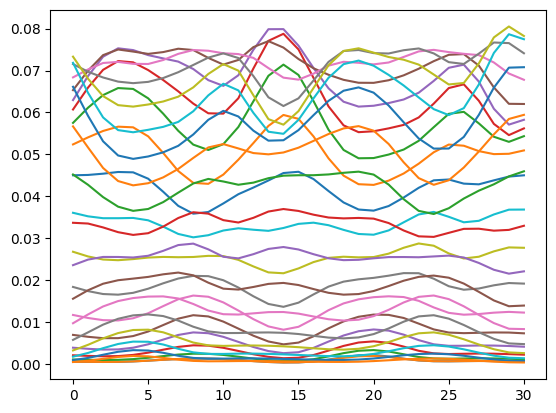

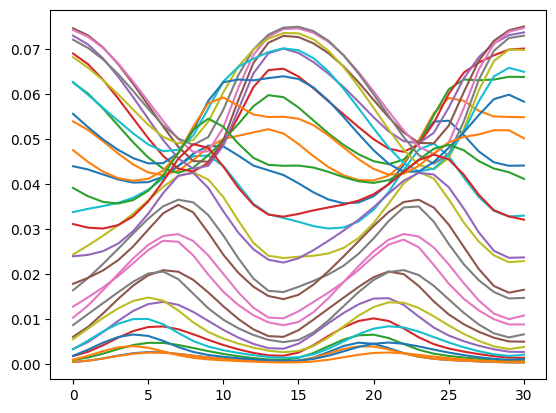

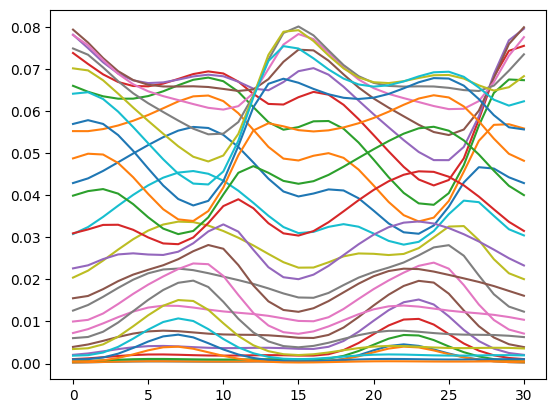

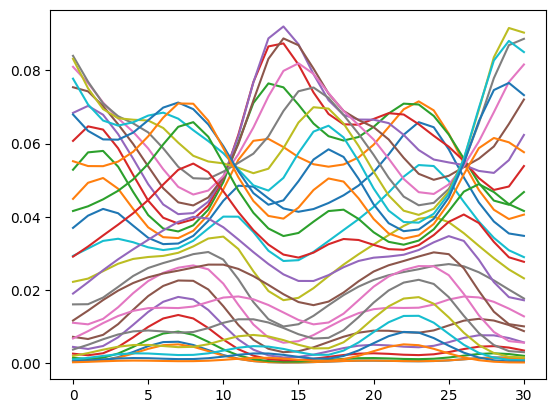

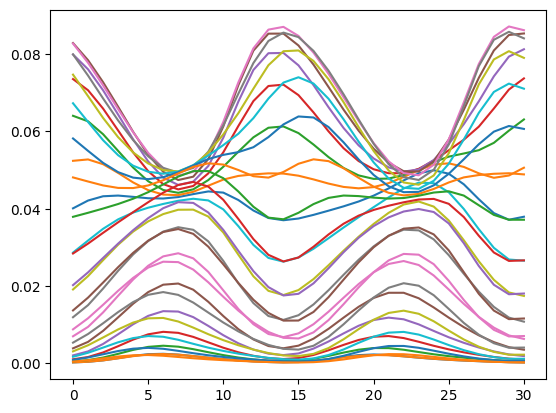

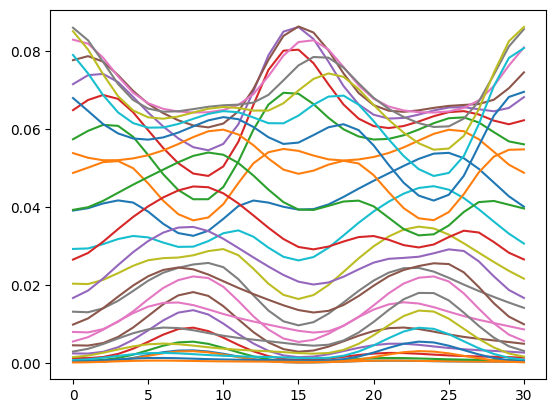

In [58]:
import matplotlib.pyplot as plt

prototypes = []
for label in range(10):
    prototypes.append(pipeline.ect_train[pipeline.y_train == label].mean(axis=0))
def get_pdf(ipt_x, n_pts):
    p = np.zeros(ipt_x.shape)
    for i in range(ipt_x.shape[0]):
        for j in range(ipt_x.shape[1]):
            p[i][j] = ipt_x[i][j] - ipt_x[i][j-1] if j > 0 else ipt_x[i][j]
    p /= n_pts
    return p

for i in range(len(prototypes)):
    plt.plot(get_pdf(prototypes[i], 512))
    plt.show()

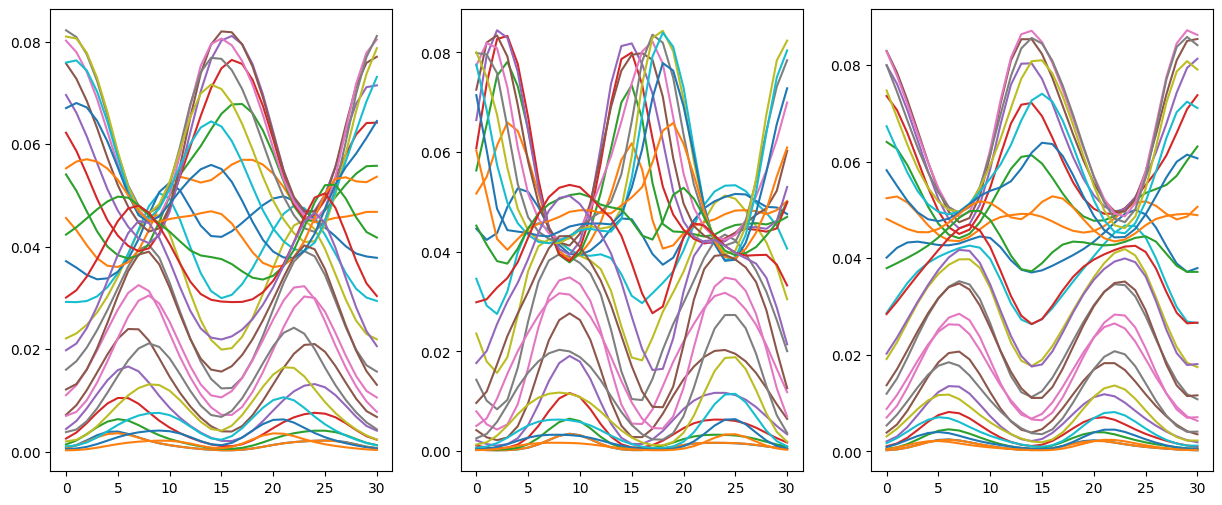

In [59]:
fig , axes = plt.subplots(1, 3, figsize=(15, 6))
j = 1
bitmap = pipeline.y_test != y_pred
for i in range(len(axes)):
    if i == 0:
        axes[i].plot(get_pdf(prototypes[y_pred[bitmap][j]], 512))
    elif i == len(axes) -1:
        axes[i].plot(get_pdf(prototypes[pipeline.y_test[bitmap][j]], 512))
    else:
        #axes[i].plot(get_pdf(pipeline.ect_train[pipeline.y_train == label][idx], 512))
        axes[i].plot(get_pdf(pipeline.ect_test[bitmap][j], 512))
    
plt.show()

Prediction: 3, Actual: 8


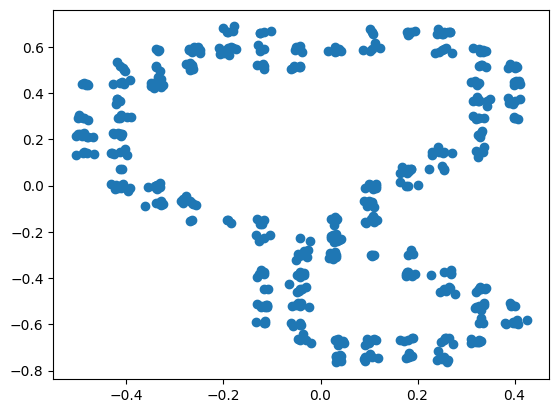

In [61]:
sample = pipeline.X_test[bitmap][j]
plt.scatter(sample[:, 0], sample[:, 1])
print(f"Prediction: {y_pred[bitmap][j]}, Actual: {pipeline.y_test[bitmap][j]}")


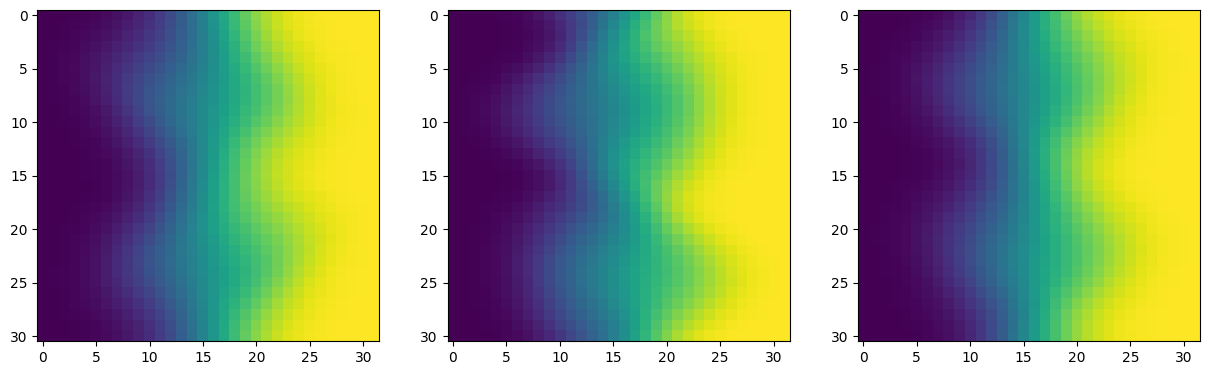

In [63]:
fig , axes = plt.subplots(1, 3, figsize=(15, 6))
j = 1
bitmap = pipeline.y_test != y_pred
for i in range(len(axes)):
    if i == 0:
        axes[i].imshow(prototypes[y_pred[bitmap][j]].reshape(pipeline.num_directions, pipeline.num_thresholds))
    elif i == len(axes) -1:
        axes[i].imshow(prototypes[pipeline.y_test[bitmap][j]].reshape(pipeline.num_directions, pipeline.num_thresholds))
    else:
        #axes[i].plot(get_pdf(pipeline.ect_train[pipeline.y_train == label][idx], 512))
        axes[i].imshow(pipeline.ect_test[bitmap][j].reshape(pipeline.num_directions, pipeline.num_thresholds))
    
plt.show()

In [13]:
plt.imshow(pipeline.ect_test[pipeline.y_test == 3][1].reshape(pipeline.num_directions, 2*pipeline.num_thresholds))
plt.show()
plt.imshow(pipeline.ect_test[pipeline.y_test == 8][3].reshape(pipeline.num_directions, 2*pipeline.num_thresholds))

ValueError: cannot reshape array of size 240 into shape (15,32)

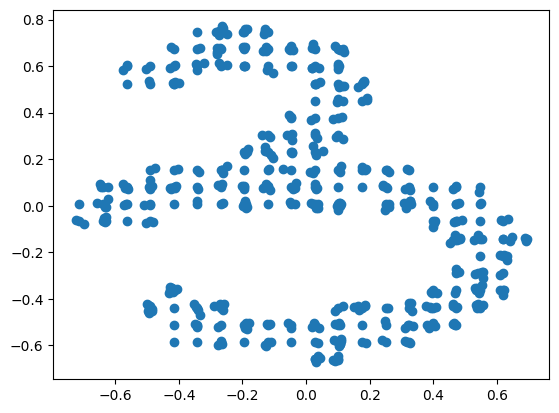

In [80]:
sample = pipeline.X_test[pipeline.y_test == 3][3]
plt.scatter(sample[:, 0], sample[:, 1])

In [2]:
pipeline.extract_features(use_smooth=True, lambda_val=10.0)

# Run Random Forest
pipeline.fit_random_forest(n_estimators=200)
pipeline.evaluate(model_type='rf')

Extracting SECT (Smooth) features...
Fitting Random Forest...
--- RF Evaluation ---
Accuracy: 0.8944
              precision    recall  f1-score   support

           0       0.95      0.94      0.94      1175
           1       0.96      0.98      0.97      1322
           2       0.86      0.92      0.89      1174
           3       0.87      0.85      0.86      1219
           4       0.89      0.89      0.89      1176
           5       0.88      0.87      0.87      1104
           6       0.93      0.94      0.94      1177
           7       0.87      0.88      0.88      1299
           8       0.85      0.82      0.84      1160
           9       0.87      0.85      0.86      1194

    accuracy                           0.89     12000
   macro avg       0.89      0.89      0.89     12000
weighted avg       0.89      0.89      0.89     12000



0.8944166666666666

## Ablation Study
Increasing the number of directions

In [2]:
# Example Execution:
pipeline = PointCloudPipeline(num_directions=9, num_thresholds=32)
pipeline.load_and_preprocess('mnist_512_pc.npz')
pipeline.extract_features()

# Run Random Forest
pipeline.fit_random_forest(n_estimators=200)
pipeline.evaluate(model_type='rf')

# Run SVC
pipeline.fit_svc(C=10.0)
pipeline.evaluate(model_type='svc')

Extracting features...
Fitting Random Forest...
--- RF Evaluation ---
Accuracy: 0.9473
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1175
           1       0.98      0.98      0.98      1322
           2       0.94      0.96      0.95      1174
           3       0.92      0.92      0.92      1219
           4       0.95      0.95      0.95      1176
           5       0.95      0.93      0.94      1104
           6       0.96      0.98      0.97      1177
           7       0.95      0.95      0.95      1299
           8       0.92      0.92      0.92      1160
           9       0.92      0.91      0.92      1194

    accuracy                           0.95     12000
   macro avg       0.95      0.95      0.95     12000
weighted avg       0.95      0.95      0.95     12000

Fitting SVC...
--- SVC Evaluation ---
Accuracy: 0.9302
              precision    recall  f1-score   support

           0       0.95      0.97      0.96 

0.9301666666666667

In [3]:
# Example Execution:
pipeline = PointCloudPipeline(num_directions=15, num_thresholds=32)
pipeline.load_and_preprocess('mnist_512_pc.npz')
pipeline.extract_features()

# Run Random Forest
pipeline.fit_random_forest(n_estimators=200)
pipeline.evaluate(model_type='rf')

# Run SVC
pipeline.fit_svc(C=10.0)
pipeline.evaluate(model_type='svc')

Extracting features...
Fitting Random Forest...
--- RF Evaluation ---
Accuracy: 0.9477
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1175
           1       0.98      0.98      0.98      1322
           2       0.94      0.96      0.95      1174
           3       0.92      0.92      0.92      1219
           4       0.95      0.95      0.95      1176
           5       0.94      0.93      0.94      1104
           6       0.96      0.98      0.97      1177
           7       0.95      0.95      0.95      1299
           8       0.93      0.92      0.92      1160
           9       0.92      0.91      0.92      1194

    accuracy                           0.95     12000
   macro avg       0.95      0.95      0.95     12000
weighted avg       0.95      0.95      0.95     12000

Fitting SVC...
--- SVC Evaluation ---
Accuracy: 0.9309
              precision    recall  f1-score   support

           0       0.95      0.96      0.96 

0.9309166666666666